# DineAnalytics: Uncovering Success Patterns in the Global Restaurant Market
**Organization:** Cognifyz Technologies  
**Project Title:** DineAnalytics: Uncovering Success Patterns in the Global Restaurant Market

## 🎯 Objective
The goal is to analyze trends in cuisines, city distribution, pricing, ratings, and service availability using data science techniques.

## 📂 Dataset Description
The dataset contains information about various restaurants, including name, city, cuisines, price range, ratings, votes, etc.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set(style="whitegrid")
%matplotlib inline

# 1. Load the dataset
df = pd.read_csv('Dataset  (1).csv')

# 2. Basic Data Exploration & Cleaning
print("Dataset Shape:", df.shape)

# Handling missing values in Cuisines (filling with 'Unknown')
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
df.head()

Dataset Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 🔹 Level 1: Basic Data Analysis

### 1.1 Top Cuisines Analysis
- Identify the top 3 most common cuisines.
- Calculate the percentage of restaurants serving these cuisines.

In [6]:
# Split cuisines and count occurrences
cuisines_series = df['Cuisines'].str.split(', ')
all_cuisines = [cuisine for sublist in cuisines_series for cuisine in sublist]
cuisine_counts = pd.Series(all_cuisines).value_counts()

top_3_cuisines = cuisine_counts.head(3)
total_restaurants = len(df)
percentage_top_3 = (top_3_cuisines / total_restaurants) * 100

print("Top 3 Cuisines:\n", top_3_cuisines)
print("\nPercentage of restaurants serving these cuisines:\n", percentage_top_3)

Top 3 Cuisines:
 North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

Percentage of restaurants serving these cuisines:
 North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64


### 1.2 City-Based Analysis
- Determine the city with the highest number of restaurants.
- Compute the average rating for restaurants in each city.

In [7]:
city_counts = df['City'].value_counts()
highest_restaurant_city = city_counts.idxmax()
avg_rating_per_city = df.groupby('City')['Aggregate rating'].mean()
highest_avg_rating_city = avg_rating_per_city.idxmax()

print(f"City with the highest number of restaurants: {highest_restaurant_city} ({city_counts.max()})")
print(f"City with the highest average rating: {highest_avg_rating_city} ({avg_rating_per_city.max():.2f})")

City with the highest number of restaurants: New Delhi (5473)
City with the highest average rating: Inner City (4.90)


### 1.3 Price Range Distribution
- Visualize the distribution of price ranges.

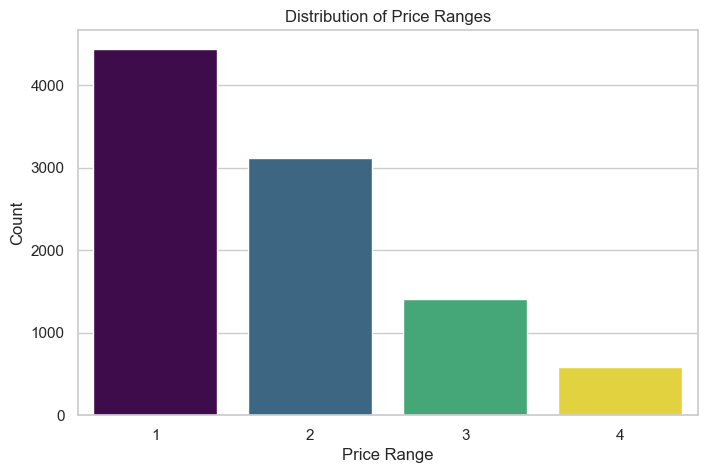

Percentage distribution of restaurants across price categories:
 Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: proportion, dtype: float64


In [8]:
price_range_dist = df['Price range'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Price range', palette='viridis', hue='Price range', legend=False)
plt.title('Distribution of Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Count')
plt.show()

print("Percentage distribution of restaurants across price categories:\n", price_range_dist)

### 1.4 Online Delivery Analysis
- Determine the percentage of restaurants offering online delivery.
- Compare average ratings of restaurants with and without online delivery.

In [9]:
online_delivery_perc = (df['Has Online delivery'].value_counts(normalize=True) * 100).get('Yes', 0)
avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print(f"Percentage of restaurants offering online delivery: {online_delivery_perc:.2f}%")
print("\nAverage ratings comparison:\n", avg_rating_delivery)

Percentage of restaurants offering online delivery: 25.66%

Average ratings comparison:
 Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


## 🔹 Level 2: Intermediate Data Analysis

### 2.1 Cuisine Combination Analysis
- Identify the most common cuisine combinations.

In [10]:
common_combinations = df['Cuisines'].value_counts().head(10)
top_combos = common_combinations.index
avg_rating_combos = df[df['Cuisines'].isin(top_combos)].groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

print("Top 10 Most Common Cuisine Combinations:\n", common_combinations)
print("\nAverage Ratings for these combinations:\n", avg_rating_combos)

Top 10 Most Common Cuisine Combinations:
 Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

Average Ratings for these combinations:
 Cuisines
Cafe                              2.890970
North Indian, Mughlai             2.888623
North Indian, Mughlai, Chinese    2.568528
North Indian, Chinese             2.421722
Bakery, Desserts                  2.317647
Street Food                       2.161745
Fast Food                         2.118362
Chinese                           2.042090
Bakery                            1.924312
North Indian                      1.672329
Name: Aggregate rating, dtype: float64


### 2.2 Geographical Analysis
- Plot restaurant locations using latitude and longitude.

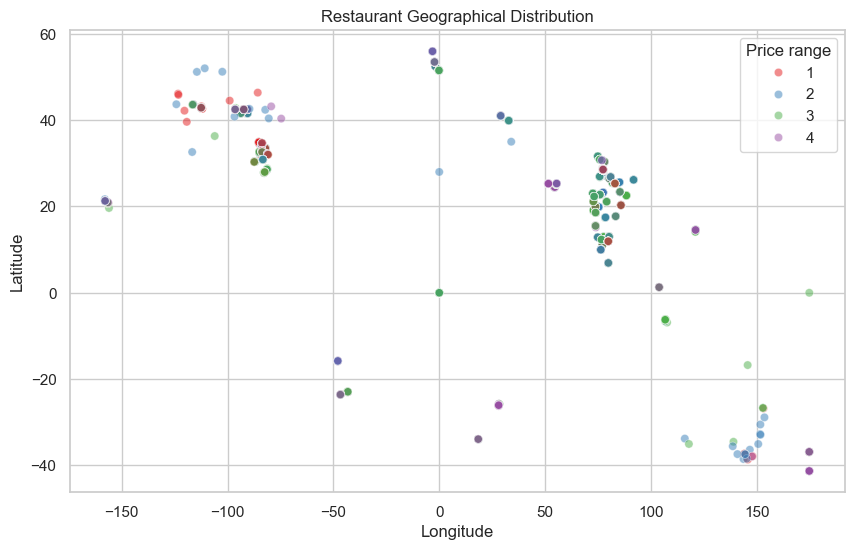

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', alpha=0.5, hue='Price range', palette='Set1')
plt.title('Restaurant Geographical Distribution')
plt.show()

### 2.3 Restaurant Chain Analysis
- Detect restaurant chains based on repeated names.

In [12]:
chain_counts = df['Restaurant Name'].value_counts()
chains = chain_counts[chain_counts > 1]
chain_data = df[df['Restaurant Name'].isin(chains.index)]
chain_stats = chain_data.groupby('Restaurant Name').agg({'Aggregate rating': 'mean', 'Votes': 'sum'}).sort_values(by='Votes', ascending=False)

print(f"Number of restaurant chains detected: {len(chains)}")
print("Top 5 Chains by popularity (Votes):\n", chain_stats.head(5))

Number of restaurant chains detected: 734
Top 5 Chains by popularity (Votes):
                            Aggregate rating  Votes
Restaurant Name                                   
Barbeque Nation                    4.353846  28142
AB's - Absolute Barbecues          4.825000  13400
Big Chill                          4.475000  10853
Farzi Cafe                         4.366667  10098
Truffles                           3.950000   9682


## 🔹 Level 3: Advanced Analysis

### 3.1 Votes vs Ratings
- Analyze correlation between votes and ratings.

Correlation between Votes and Aggregate Rating: 0.3137


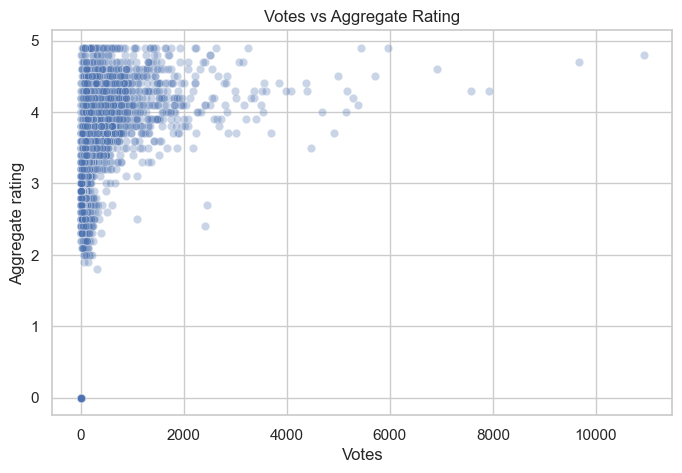

In [13]:
correlation = df['Votes'].corr(df['Aggregate rating'])
print(f"Correlation between Votes and Aggregate Rating: {correlation:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Votes', y='Aggregate rating', alpha=0.3)
plt.title('Votes vs Aggregate Rating')
plt.show()

### 3.2 Price vs Services
- Examine relationship between price range and services (Online delivery, Table booking).

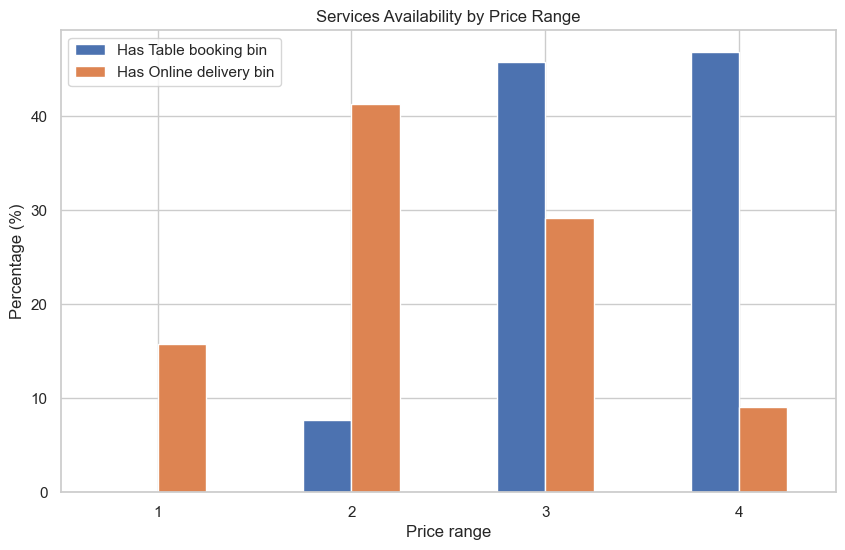

In [14]:
df['Has Table booking bin'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery bin'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})
price_services = df.groupby('Price range')[['Has Table booking bin', 'Has Online delivery bin']].mean() * 100

price_services.plot(kind='bar', figsize=(10, 6))
plt.title('Services Availability by Price Range')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.show()